## Dismantling with graph discriminator



In [1]:
import torch
import igraph as ig
from networks.dismantle import load_sac_dismantler

num_features = 16
num_heads = 4
num_mps = 6
device = "cuda:0"

policy_pl, _, _, _, _ = load_sac_dismantler(
    num_features, num_heads, num_mps, 
    "mind", device, ckpt_pth='saved/mind/mind.ckpt'
)
policy_com, _, _, _, _ = load_sac_dismantler(
    num_features, num_heads, num_mps, 
    "mind", device, ckpt_pth='saved/mind/mind_SBM_16799.ckpt'
)

d:\Anaconda3\envs\torch_py38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
from discriminator import Discriminator
from networks.gnn import GNN_ENCODER
from utils.graph_data import Batch, ig_to_data
from torch_scatter import scatter_mean
from utils.graph_models import SBM,BA

graph_embed_dim = num_features * num_mps  # KF

encoder = GNN_ENCODER['hgnn_v3'](num_features, num_heads, num_mps).to(device)
discriminator = Discriminator(graph_embed_dim).to(device)

ckpt = torch.load("saved/discriminator/discriminator_best.ckpt", map_location=device)
encoder.load_state_dict(ckpt["encoder_state_dict"])
discriminator.load_state_dict(ckpt["discriminator_state_dict"])

g = ig.Graph.Erdos_Renyi(100, 0.1)
g = SBM(120,p_in=0.01,p_out=0.0075,num_blocks=2)
g = BA(120,m=4)
g = Batch(device, [ig_to_data(g)])
with torch.no_grad() if not encoder.training else torch.enable_grad():
    out = encoder(g)  # [N_total, 2*KF]
    embed_dim = out.shape[1] // 2
    graph_emb = scatter_mean(
        out[:, embed_dim:], g.batch_non_omni, dim=0, dim_size=g.batch_size
    )  # [B, KF]

print(discriminator(graph_emb))
print((discriminator(graph_emb) >= 0).long())


tensor([5.3668], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([1], device='cuda:0')


In [86]:
import utils
import igraph as ig
from networks.dismantle import load_sac_dismantler

def mind_wrapper(graph:ig.Graph,policy,step_ratio):
    '''
    same return with preprocess
    removals: complete solution
    removed_sizes: cumulative removed number at each step, start from 0
    lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
    '''
    
    from utils.validate import validate_one_graph
    auc, robustness, _, removals = validate_one_graph(graph,policy=policy,step_ratio=step_ratio,log_removals=True)

    return auc, robustness, removals

g = ig.Graph.Erdos_Renyi(100, 0.1)
g['name'] = 'test'
mind_wrapper(g,policy_pl,step_ratio = 0.0)

Loaded graph test
Graph: test, AUC=34.284167, Robustness=0.338200, Steps=56


(34.28416666666666,
 0.33819999999999995,
 [75,
  74,
  62,
  31,
  60,
  34,
  90,
  84,
  65,
  9,
  13,
  98,
  70,
  37,
  86,
  85,
  87,
  49,
  95,
  79,
  52,
  41,
  57,
  26,
  66,
  76,
  28,
  67,
  55,
  63,
  2,
  54,
  39,
  36,
  81,
  0,
  94,
  24,
  45,
  93,
  40,
  6,
  96,
  42,
  50,
  51,
  7,
  1,
  16,
  18,
  19,
  80,
  88,
  17,
  92,
  12])

In [121]:
import utils
import importlib
importlib.reload(utils)
from utils.validate import validate_step
import numpy as np
from utils.graph_data import Batch, ig_to_data

def mind_dismantling_with_disc(graph, policy_com,policy_pl, discriminator, encoder, device, step_ratio=0.025):
    """Dismantle the graph using the policy and discriminator."""
    
    from env.env import DismantleEnv
    env = DismantleEnv(graph_data=[graph], batch_size=1, is_val=True)
    obs_list, _ = env.reset()

    finished = False

    while not finished:
        g = Batch(device, [ig_to_data(g) for g in obs_list])
        with torch.no_grad():
            out = encoder(g)  # [N_total, 2*KF]
            embed_dim = out.shape[1] // 2
            graph_emb = scatter_mean(
                out[:, embed_dim:], g.batch_non_omni, dim=0, dim_size=g.batch_size
            )  # [B, KF]

        print(discriminator(graph_emb))
        if discriminator(graph_emb) < 0:
            act = validate_step(obs_list,policy_com,device,step_size=1)
        else:
            act = validate_step(obs_list,policy_pl,device,step_size=1)

        obs_next_list, rew_arr, done_arr, info_list = env.step(np.array(act))
        # obs_next_list, _ = env.reset_async(done_arr)
        if len(info_list) > 0 and done_arr[0]:
            removals = info_list[0].removals
            auc = info_list[0].auc
            robustness = info_list[0].robustness
            gcc_eps = info_list[0].gcc_eps
            finished = True
            break
        obs_list = np.array(obs_next_list)

    return auc, robustness, removals

g = ig.Graph.Erdos_Renyi(100, 0.1)
# g = SBM(120,p_in=0.01,p_out=0.0075,num_blocks=2)
g = BA(120,m=4)
g['name'] = 'test'
mind_dismantling_with_disc(g,
                            policy_com, policy_pl,
                            discriminator, encoder,
                            device, step_ratio = 0.0)

Loaded graph test
tensor([4.7281], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([4.6085], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([0.6482], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([1.2788], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([0.4606], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-6.0796], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-5.8309], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-4.5151], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-7.2399], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([1.0875], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([2.7935], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-1.2661], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-2.3593], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-1.9667], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-1.7075], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-3.5426], device='cuda:0', grad_fn=<

(29.52777777777777,
 0.24194444444444446,
 [7,
  6,
  1,
  0,
  23,
  5,
  4,
  15,
  24,
  30,
  29,
  9,
  8,
  3,
  11,
  18,
  14,
  21,
  31,
  53,
  60,
  33,
  47,
  59,
  35,
  2,
  70,
  32,
  50,
  28,
  13,
  56,
  10,
  38,
  113,
  19,
  65,
  52,
  27,
  108,
  34,
  112,
  91])

IGRAPH U--- 16167 20242 -- test
+ attr: name (g)
Loaded graph test
Graph: test, AUC=344.973202, Robustness=0.021312, Steps=500
Loaded graph test
Graph: test, AUC=420.618230, Robustness=0.025991, Steps=612
Loaded graph test
tensor([-0.4732], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-0.9082], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([1.1112], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([0.8453], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-1.0055], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-1.5770], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-0.4677], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-0.0222], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-0.3331], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-0.2122], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([0.5580], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-1.8922], device='cuda:0', grad_fn=<SqueezeBackward1>)
tensor([-0.5288], device

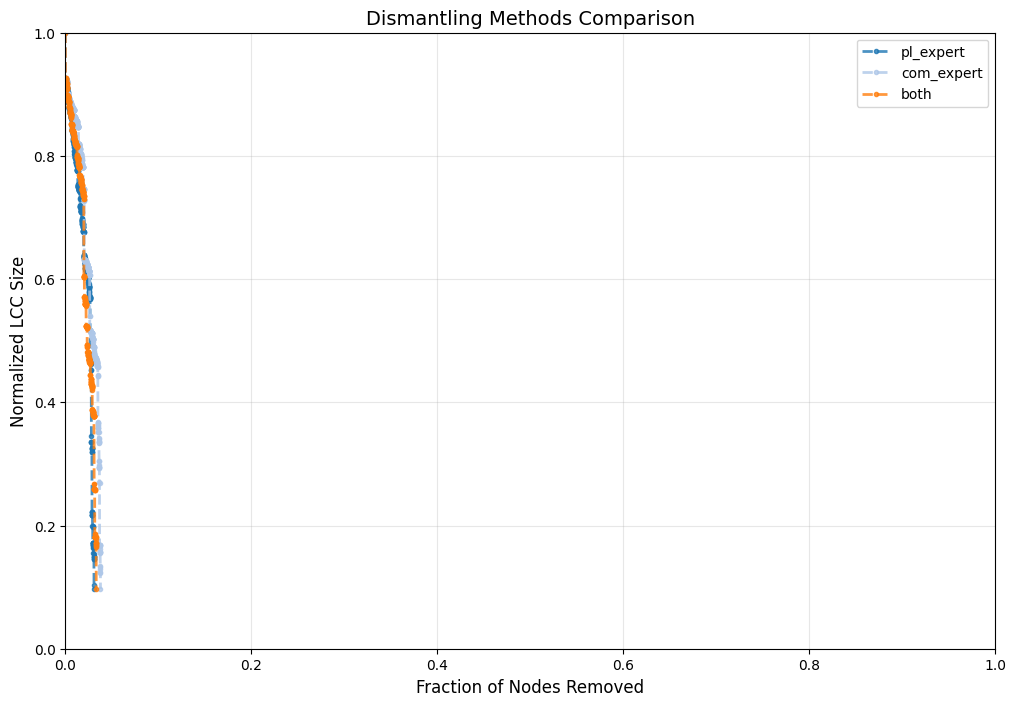

In [137]:
import pickle
from utils.common import load_g

g = load_g(f'graphs/real/bio/maayan-figeys.pkl',name='test')
g = load_g(f'graphs/real/tech/gridkit-north_america.pkl',name='test')
# g = BA(120,m=4)
# g = SBM(120,p_in=0.1,p_out=0.0075,num_blocks=2)
print(g.summary())

g['name'] = 'test'
all_results = {}

_, _, removals = mind_wrapper(g,policy_pl,step_ratio = 0.0)
all_results['pl_expert'] = removals
_, _, removals = mind_wrapper(g,policy_com,step_ratio = 0.0)
all_results['com_expert'] = removals
_, _, removals = mind_dismantling_with_disc(g,policy_com, policy_pl, discriminator, encoder, device, step_ratio = 0.0)
all_results['both'] = removals

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)